In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import csv
import math
import random
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt

import json, codecs
import seaborn as sns
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

In [2]:
# Set the path to the file you'd like to load
test_path = "fashion-mnist_test.csv"

# Load the latest version of the test data
test_data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  test_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", test_data.head())

Using Colab cache for faster access to the 'fashionmnist' dataset.
First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224   
4       0  ...         0         0         0         0         0     

In [3]:
# Set the path to the file you'd like to load
train_path = "fashion-mnist_train.csv"

# Load the latest version of the train data
train_data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  train_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", train_data.head())


Using Colab cache for faster access to the 'fashionmnist' dataset.
First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0     

In [4]:
train_data['label'].describe()
test_data['label'].describe()

#labels range from 0-9

train_data.info() #60000 entries
test_data.info() #10000 entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


In [10]:
X_train = train_data.drop(["label"], axis=1).values
Y_train = train_data.label.values
X_test = test_data.drop(["label"], axis=1).values
Y_test = test_data.label.values

print("X_train shape:", np.shape(X_train))
print("Y_train shape:", np.shape(Y_train))
print("X_test shape:", np.shape(X_test))
print("Y_test shape:", np.shape(X_train))

X_train shape: (60000, 784)
Y_train shape: (60000,)
X_test shape: (10000, 784)
Y_test shape: (60000, 784)


In [11]:
#normalise the data

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

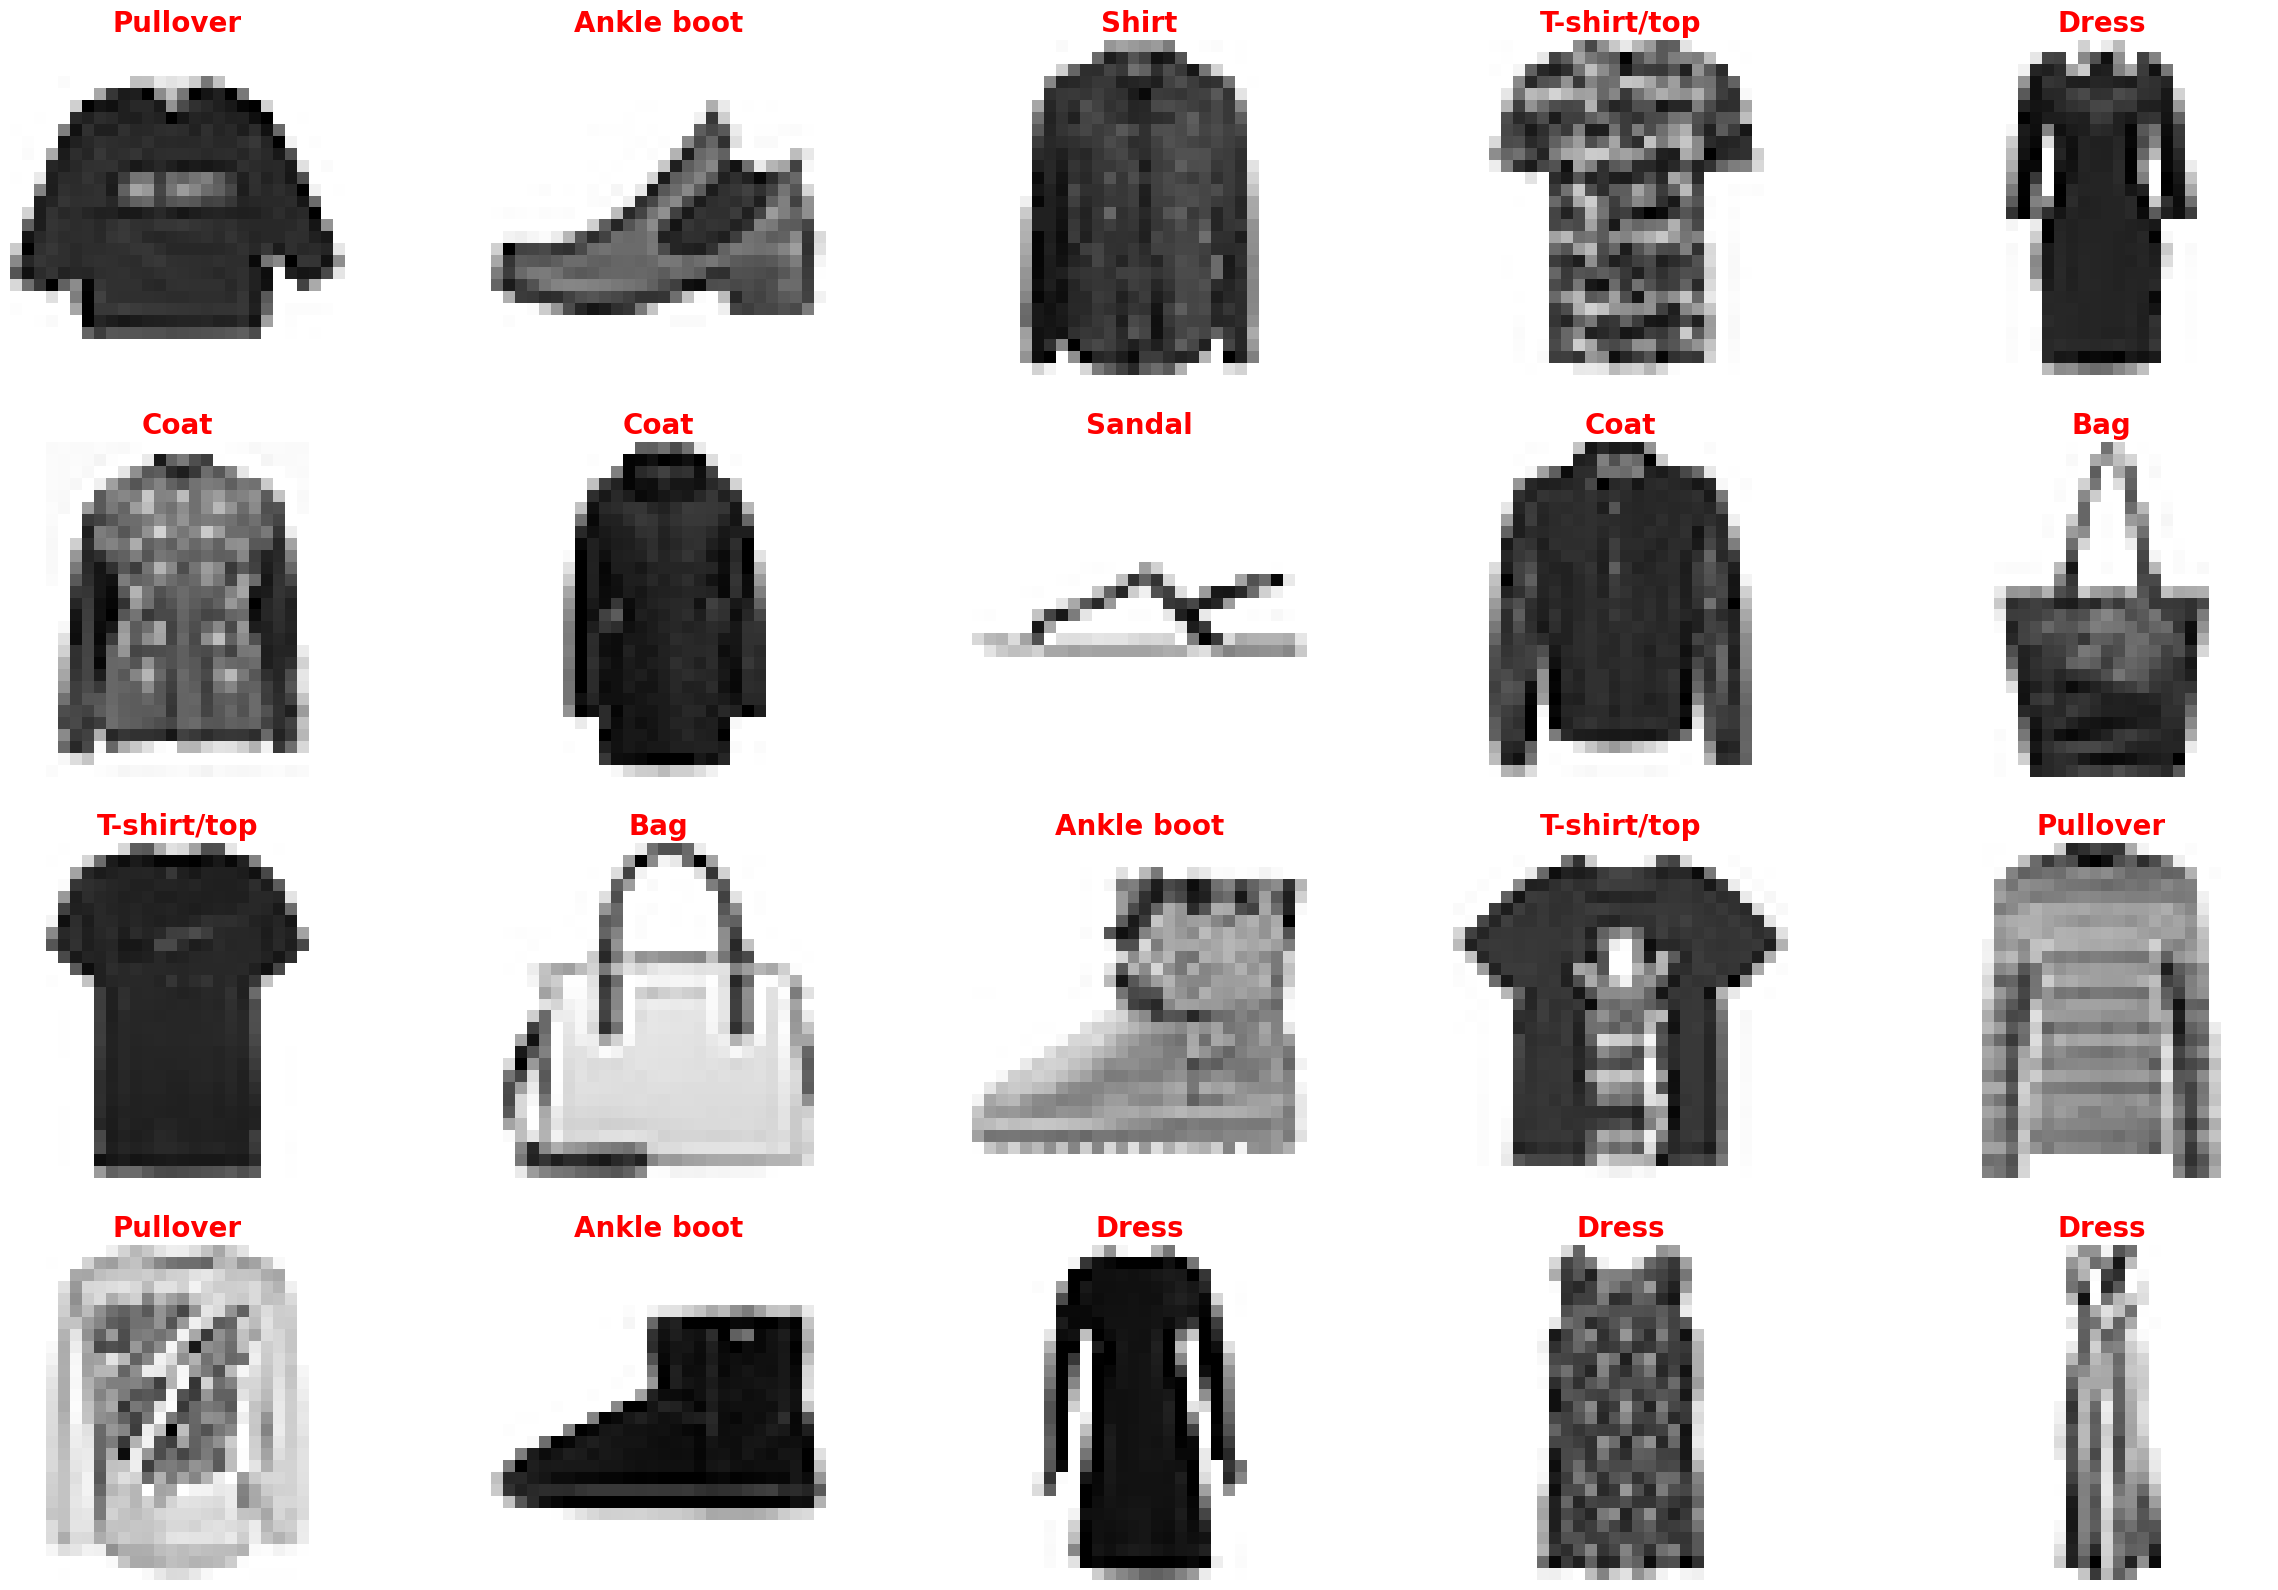

In [12]:
plt.figure(figsize=(30,20))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gist_yarg")
    plt.title("T-shirt/top" if Y_train[i] == 0
              else "Trouser" if Y_train[i] == 1
              else "Pullover" if Y_train[i] == 2
              else "Dress" if Y_train[i] == 3
              else "Coat" if Y_train[i] == 4
              else "Sandal" if Y_train[i] == 5
              else "Shirt" if Y_train[i] == 6
              else "Sneaker" if Y_train[i] == 7
              else "Bag" if Y_train[i] == 8
              else "Ankle boot",
              size = 20, color = "red", fontweight = "bold")
    plt.axis("off")

plt.show()

In [14]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_img = Input(shape = (784,))

In [15]:
encoded = Dense(32, activation="relu")(input_img)
encoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

In [16]:
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer="rmsprop", loss="binary_crossentropy")

In [17]:
hist = autoencoder.fit(X_train,
                       X_train,
                       epochs=250,
                       batch_size=256,
                       shuffle=True,
                       validation_data=(X_train, X_train))

Epoch 1/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.4557 - val_loss: 0.3822
Epoch 2/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3673 - val_loss: 0.3519
Epoch 3/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3430 - val_loss: 0.3353
Epoch 4/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3309 - val_loss: 0.3278
Epoch 5/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3257 - val_loss: 0.3232
Epoch 6/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3223 - val_loss: 0.3203
Epoch 7/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3198 - val_loss: 0.3191
Epoch 8/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3178 - val_loss: 0.3169
Epoch 9/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3162 - val_loss: 0.3140
Epoch 10/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3149 - val_loss: 0.3143
Epoch 11/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3137 - val_loss: 0.3131
Epoch 12/250
235/235 ━━━━━━━━━

In [18]:
encoder = Model(input_img, encoded)
encoded_img = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


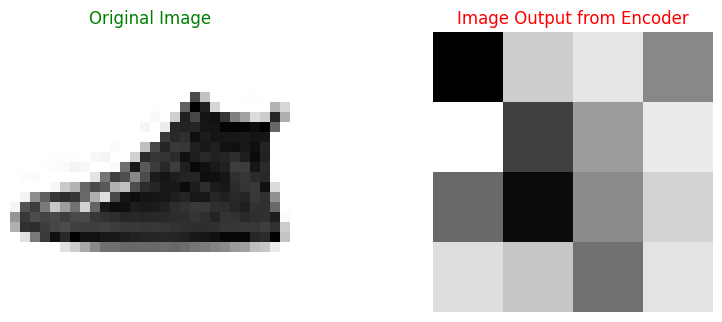

In [21]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(X_test[25].reshape(28,28), cmap="gist_yarg")
plt.title("Original Image", color = "green")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(encoded_img[25].reshape(4,4), cmap="gist_yarg")
plt.title("Image Output from Encoder", color = "red")
plt.axis("off")
plt.show()

In [22]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


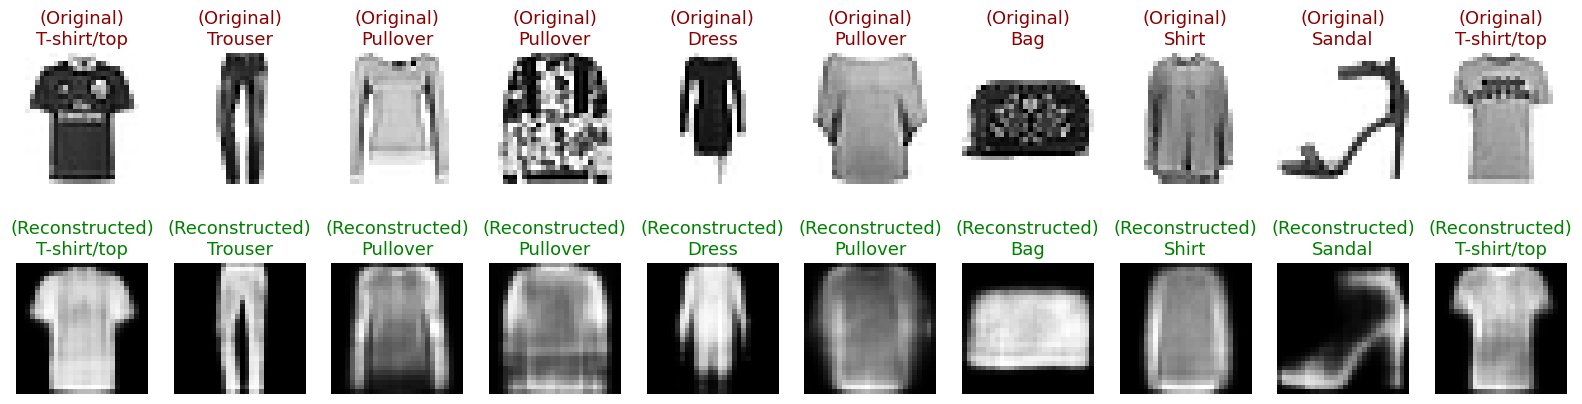

In [23]:
plt.figure(figsize=(20, 5))
for i in range(10):

    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gist_yarg")
    plt.title("(Original)\nT-shirt/top" if Y_test[i] == 0
              else "(Original)\nTrouser" if Y_test[i] == 1
              else "(Original)\nPullover" if Y_test[i] == 2
              else "(Original)\nDress" if Y_test[i] == 3
              else "(Original)\nCoat" if Y_test[i] == 4
              else "(Original)\nSandal" if Y_test[i] == 5
              else "(Original)\nShirt" if Y_test[i] == 6
              else "(Original)\nSneaker" if Y_test[i] == 7
              else "(Original)\nBag" if Y_test[i] == 8
              else "(Original)\nAnkle boot", size = 13, color = "darkred")
    plt.axis("off")

    plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.title("(Reconstructed)\nT-shirt/top" if Y_test[i] == 0
              else "(Reconstructed)\nTrouser" if Y_test[i] == 1
              else "(Reconstructed)\nPullover" if Y_test[i] == 2
              else "(Reconstructed)\nDress" if Y_test[i] == 3
              else "(Reconstructed)\nCoat" if Y_test[i] == 4
              else "(Reconstructed)\nSandal" if Y_test[i] == 5
              else "(Reconstructed)\nShirt" if Y_test[i] == 6
              else "(Reconstructed)\nSneaker" if Y_test[i] == 7
              else "(Reconstructed)\nBag" if Y_test[i] == 8
              else "(Reconstructed)\nAnkle boot", size = 13, color = "green")
    plt.axis("off")

plt.show()

History Keys --> dict_keys(['loss', 'val_loss'])


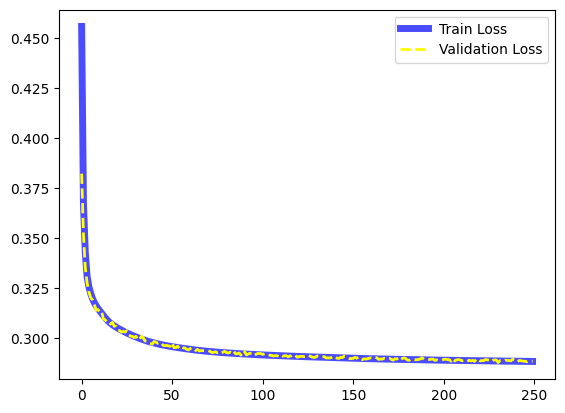

In [28]:
print("History Keys -->", hist.history.keys())

plt.plot(hist.history["loss"], label = "Train Loss", color = "blue", alpha=0.7, linewidth=5)
plt.plot(hist.history["val_loss"], label = "Validation Loss", color = "yellow", linewidth=2, linestyle='dashed')

plt.legend()
plt.show()